<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-5---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Entregable_Tarea_5_1_Alfaro_Cruz_Perez_Rupit_Medea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contaminación Atmosférica y Calidad del Aire (PM2.5)

## Exploración y Preprocesamiento
Rúbrica: 15% Manejo adecuado de valores nulos, codificación de categóricas y escalamiento de variables (crítico para GLM, $L_1$ / $L_2$ y Redes Neuronales).

## Resumen de la programación realizada en este código

1) Se revisa la información para poder determinar el tipo de datos y sus estadísticos para poder decir el tratamiento de los datos.
2) Se transformó la única variable categórica (cbwd) y se separó por columnas para poderla utilizar en el modelado.

3) Creamos tres ejercicios de df imputados, el primero con medianas, el segundo con medias y el tercero con mice.
4) Decidimos para lo que sigue en el código, trabajar con el df al cuál se le eliminaron los nulos  y con mice para hacer un comparativo entre los modelos.

Observaciones:  

5) La información cuenta con registros por hora durante todos los días a lo largo de los 5 años.  
6) Encontramos que: La información solo tenía datos con NA en la columna por modelar (pm2.5) y representan menos del 4.72% del total de datos.
7) Hay dos columns (ls y lr) que más del 75% de sus datos son cero por lo que al analizarlos se categorizan varios de sus valores como outliers.

In [58]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.compose import ColumnTransformer

In [59]:
# Importar la información
df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

In [60]:
# Se revisa el número de registros
print("Numero de filas del dataset: ", len(df))

Numero de filas del dataset:  43824


In [61]:
# Mostrar las primeras 5 filas
df.sample(10)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
7546,7547,2010,11,11,10,17.0,-2,9.0,1010.0,NW,35.30,0,0
10685,10686,2011,3,22,5,9.0,-22,0.0,1031.0,NW,189.97,0,0
11537,11538,2011,4,26,17,13.0,3,15.0,1007.0,NW,21.01,0,0
1745,1746,2010,3,14,17,94.0,-1,0.0,1018.0,cv,0.45,14,0
30408,30409,2013,6,21,0,102.0,18,24.0,1009.0,NE,0.89,0,0
12380,12381,2011,5,31,20,NaN,9,23.0,1004.0,NW,142.16,0,0
19006,19007,2012,3,2,22,159.0,-2,0.0,1029.0,NE,0.89,0,0
18467,18468,2012,2,9,11,63.0,-18,-1.0,1027.0,cv,1.79,0,0
21635,21636,2012,6,20,11,72.0,18,29.0,1003.0,cv,4.02,0,0
2999,3000,2010,5,5,23,10.0,-1,15.0,1004.0,NW,134.10,0,0


# Glosario de Columnas Relevantes

Se estandarizaron todos los nombres de las columnas a mayúsculas y sin símbolos

pm2.5 --> PM25: Concentración de partículas PM2.5 (material particulado fino)

DEWP: Punto de rocío (Dew Point)

TEMP: Temperatura ambiente

PRES: Presión atmosférica

cbwd --> WIND_DIRECTION : Dirección combinada del viento
  - NW: Viento del noroeste

  - NE: Viento del noreste

  - SE: Viento del sureste

  - cv: Calm Variable (viento muy debil o dirección variable). *Combinación de las tres anteriores, sin rumbo fijo.

lws --> WIND_SPEED: velocidad acumulada del viento

ls--> SNOW: Horas acumuladas de nieve

lr --> RAIN: Horas acumuladas de lluvia





In [62]:
# Revisar el tipos de datos y columnas presentes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [63]:
#Renombrar encabezados para sevitar problemas en la programación
df = df.rename(columns={"No": "NO",
                        "year": "YEAR",
                        "month": "MONTH",
                        "day": "DAY",
                        "hour": "HOUR",
                        "pm2.5": "PM25",
                        "DEWP": "DEWPOINT",
                        "TEMP": "TEMP",
                        "PRES": "PRESION",
                        "cbwd": "WIND_DIRECTION",
                        "Iws": "WIND_SPEED",
                        "Is": "SNOW",
                        "Ir": "RAIN"})
df.info()  # Revisar el tipos de datos y columnas presentes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NO              43824 non-null  int64  
 1   YEAR            43824 non-null  int64  
 2   MONTH           43824 non-null  int64  
 3   DAY             43824 non-null  int64  
 4   HOUR            43824 non-null  int64  
 5   PM25            41757 non-null  float64
 6   DEWPOINT        43824 non-null  int64  
 7   TEMP            43824 non-null  float64
 8   PRESION         43824 non-null  float64
 9   WIND_DIRECTION  43824 non-null  object 
 10  WIND_SPEED      43824 non-null  float64
 11  SNOW            43824 non-null  int64  
 12  RAIN            43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [64]:
# Se quería entender la cantidad y granularidad de la informacion por FECHA.
# Creación de una columna con la fecha a partir de year, month, day y hour.
# Mostrar resultados
df['FECHA'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY', 'HOUR']]) # Crea una columna con la fecha con hora
print("Rango de fechas del dataset:")
print(f"Desde: {df['FECHA'].min()} hasta {df['FECHA'].max()}")

# Observamos que las mediciones son cada hora
display(df["HOUR"].value_counts())

# Creación de otra SIN columna HOUR
df['FECHA_SIN_H'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']]) # Crea una columna con la fecha
print("Rango de fechas del dataset:")
print(f"Desde: {df['FECHA_SIN_H'].min()} hasta {df['FECHA_SIN_H'].max()}")

# Frecuencia de observaciones por día
display(df["FECHA"].value_counts())
display(df["FECHA_SIN_H"].value_counts())


Rango de fechas del dataset:
Desde: 2010-01-01 00:00:00 hasta 2014-12-31 23:00:00


,count
HOUR,
0,1826
1,1826
2,1826
3,1826
4,1826
5,1826
6,1826
7,1826
8,1826


Rango de fechas del dataset:
Desde: 2010-01-01 00:00:00 hasta 2014-12-31 00:00:00


,count
FECHA,
2014-12-31 07:00:00,1
2014-12-31 06:00:00,1
2014-12-31 05:00:00,1
2014-12-31 04:00:00,1
2014-12-31 03:00:00,1
...,...
2010-01-01 04:00:00,1
2010-01-01 03:00:00,1
2010-01-01 02:00:00,1


,count
FECHA_SIN_H,
2014-12-31,24
2010-01-01,24
2014-12-15,24
2014-12-14,24
2014-12-13,24
...,...
2010-01-07,24
2010-01-06,24
2010-01-05,24


In [56]:
# Se revisa la configuración del df y las nuevas columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   NO              43824 non-null  int64         
 1   YEAR            43824 non-null  int64         
 2   MONTH           43824 non-null  int64         
 3   DAY             43824 non-null  int64         
 4   HOUR            43824 non-null  int64         
 5   PM25            41757 non-null  float64       
 6   DEWPOINT        43824 non-null  int64         
 7   TEMP            43824 non-null  float64       
 8   PRESION         43824 non-null  float64       
 9   WIND_DIRECTION  43824 non-null  object        
 10  WIND_SPEED      43824 non-null  float64       
 11  SNOW            43824 non-null  int64         
 12  RAIN            43824 non-null  int64         
 13  FECHA           43824 non-null  datetime64[ns]
 14  FECHA_SIN_H     43824 non-null  datetime64[ns]
dtypes:

In [67]:
# Se revisa un ejemplo de 10 registros del df
df.sample(10)

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H
2514,2515,2010,4,15,18,200.0,2,8.0,1018.0,NE,1.79,0,0,2010-04-15 18:00:00,2010-04-15
34087,34088,2013,11,21,7,128.0,-7,-3.0,1026.0,NW,9.82,0,0,2013-11-21 07:00:00,2013-11-21
38340,38341,2014,5,17,12,95.0,5,26.0,1013.0,SE,4.02,0,0,2014-05-17 12:00:00,2014-05-17
41569,41570,2014,9,29,1,79.0,15,15.0,1014.0,NE,2.68,0,0,2014-09-29 01:00:00,2014-09-29
9628,9629,2011,2,6,4,17.0,-11,-4.0,1019.0,NE,7.15,0,0,2011-02-06 04:00:00,2011-02-06
33387,33388,2013,10,23,3,49.0,1,7.0,1022.0,NW,4.92,0,0,2013-10-23 03:00:00,2013-10-23
16725,16726,2011,11,28,21,50.0,-3,4.0,1031.0,cv,0.89,0,0,2011-11-28 21:00:00,2011-11-28
30381,30382,2013,6,19,21,48.0,12,32.0,1002.0,cv,3.13,0,0,2013-06-19 21:00:00,2013-06-19
39050,39051,2014,6,16,2,117.0,20,22.0,1004.0,cv,1.78,0,0,2014-06-16 02:00:00,2014-06-16
12704,12705,2011,6,14,8,133.0,16,26.0,1004.0,SE,7.16,0,0,2011-06-14 08:00:00,2011-06-14


In [65]:
# Análisis de métricas principales de la información
# Estadísticas básicas sin considerar las fechas ni variables categóricas
df.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR","FECHA", "FECHA_SIN_H" ]).describe()

,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN
count,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


Notas:
- El rango de las variables (diferente entre ellas) puede afectar el modelo por lo que es posible que se deba normalizar
- SNOW y RAIN tienen más del 75% de los datos en ceros.

En este bloque revisamos los OUTLIERS de diferentes columnas,variando el percentil y haciendo zoom o haciendo conteos

No eliminamos datos.

In [12]:
# Revisamos las cifras mayores a cierto porcentil de manera manual ya que el crecimiento de la variable pm2.5 en el Q_4 es de 137 y su máximo es 994.
# Utilizamos el P_75=137 , P_90=221  y P_99=420
# En este bloque revisamos los outliers variando el percentil, no eliminamos dato.
threshold = df['PM25'].quantile(0.75)
filtered_df = df[df['PM25'] >= threshold]
filtered_df['PM25'].describe()

,PM25
count,10506.000000
mean,226.650010
std,87.597093
min,137.000000
25%,162.000000
50%,200.000000
75%,265.000000
max,994.000000


In [66]:
# Se revisa con un conteo los valores de SNOW y RAIN por la cantidad de ceros que presentan
print(df[["SNOW", "RAIN"]].value_counts())

SNOW  RAIN
0     0       41648
      1         529
      2         316
      3         214
      4         136
              ...  
      36          1
24    0           1
25    0           1
26    0           1
27    0           1
Name: count, Length: 64, dtype: int64


Revisión de vaciós y el resultado es que sólo hay en la columna pm2.5 y son menos del 4.72%

In [13]:
# Revisión de datos nulos de la información
df.isnull().sum()

,0
NO,0
YEAR,0
MONTH,0
DAY,0
HOUR,0
PM25,2067
DEWPOINT,0
TEMP,0
PRESION,0
WIND_DIRECTION,0


In [14]:
# Porcentaje de vacíos en la información por modelar
x = 2067/43824*100
print(round(x, 3), '%')

4.717 %


# **En esta sección se grafican las 8 variables del df.**
No consideramos para graficar las relacionadas a las fechas.

Se utilizan:
- Histograma para la variable pm2.5
- Series de tiempo para todas las variables continuas
- Grafica de barras para las variables categóricas

<function matplotlib.pyplot.show(close=None, block=None)>

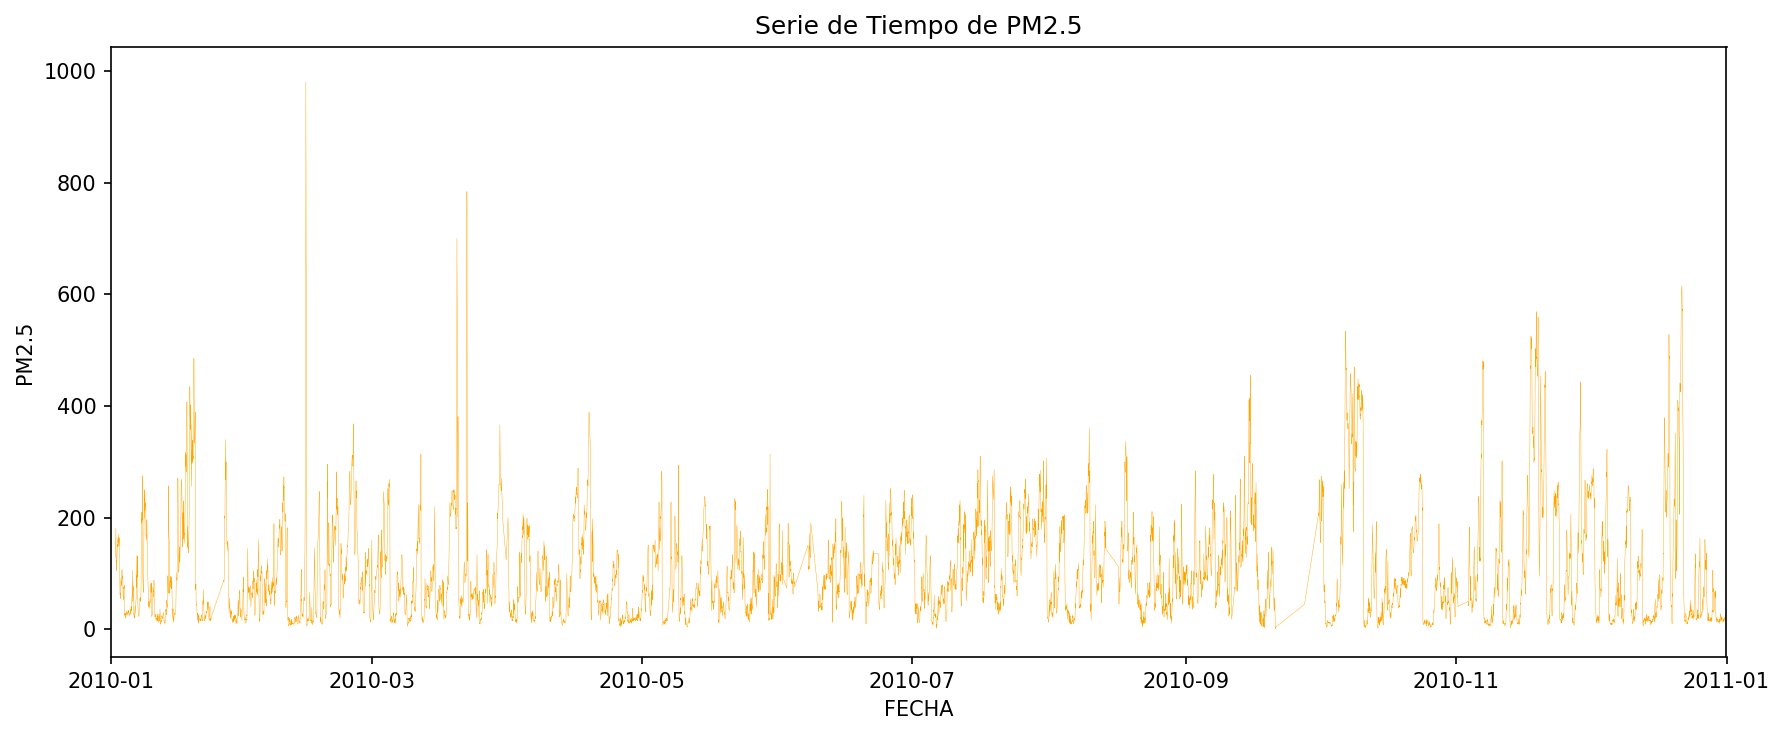

In [99]:
# # SERIE DE TIEMPO
# Serie de PM2.5,
plt.rcParams["figure.dpi"] = 150
fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x="FECHA", y="PM25",
             data=df,
             linewidth=0.2,
             color='orange'
            )
ax.set(
    ylabel="PM2.5",
    title="Serie de Tiempo de PM2.5",
)
ax.tick_params(axis="both", labelsize=10)

plt.xlim(pd.Timestamp("2010-01-01"), pd.Timestamp("2011-01-01"))
plt.tight_layout()
plt.show

# Time Series por año
# Pendiente ver si sale...

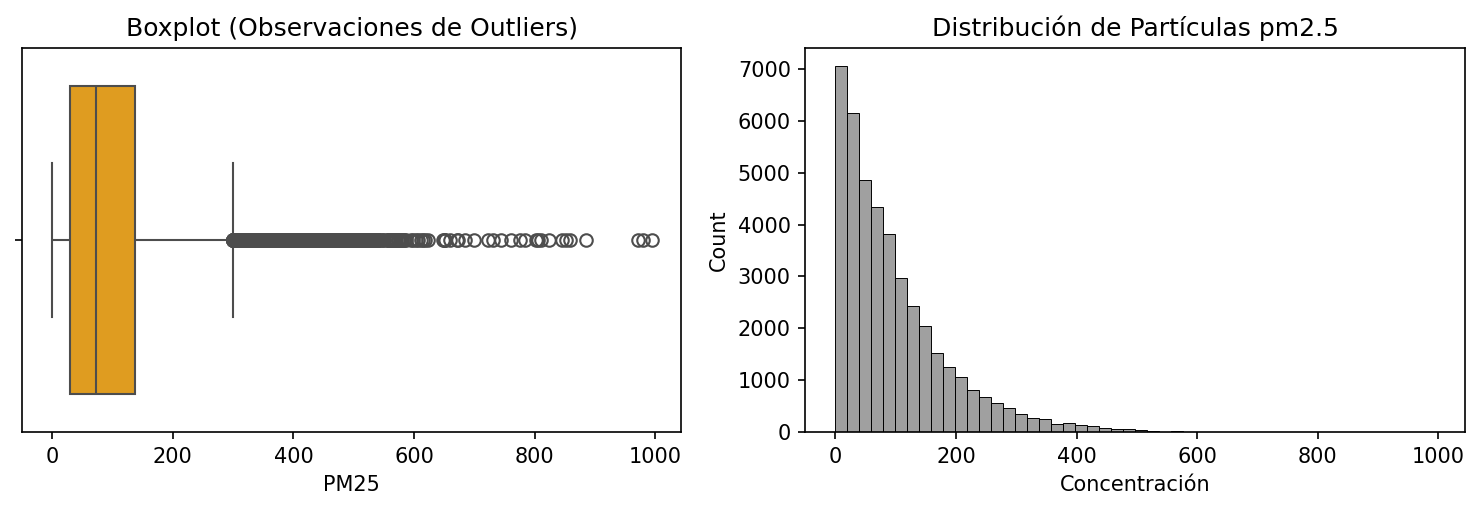

In [97]:
# HISTOGRAMA Y GRAFICO  DE CAJA Y BIGOTES
# Para elegir el metodo de imputación, observamos los outliers del dataset
plt.figure(figsize=(10, 3.5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["PM25"], color='orange')
plt.title("Boxplot (Observaciones de Outliers)")

# Gráfico para ver la distribución de pm2.5 e identificar sesgos o valores atípicos (outliers)
plt.subplot(1, 2, 2)
sns.histplot(df['PM25'], bins=50, color='grey')
plt.title('Distribución de Partículas pm2.5')
plt.xlabel('Concentración')

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

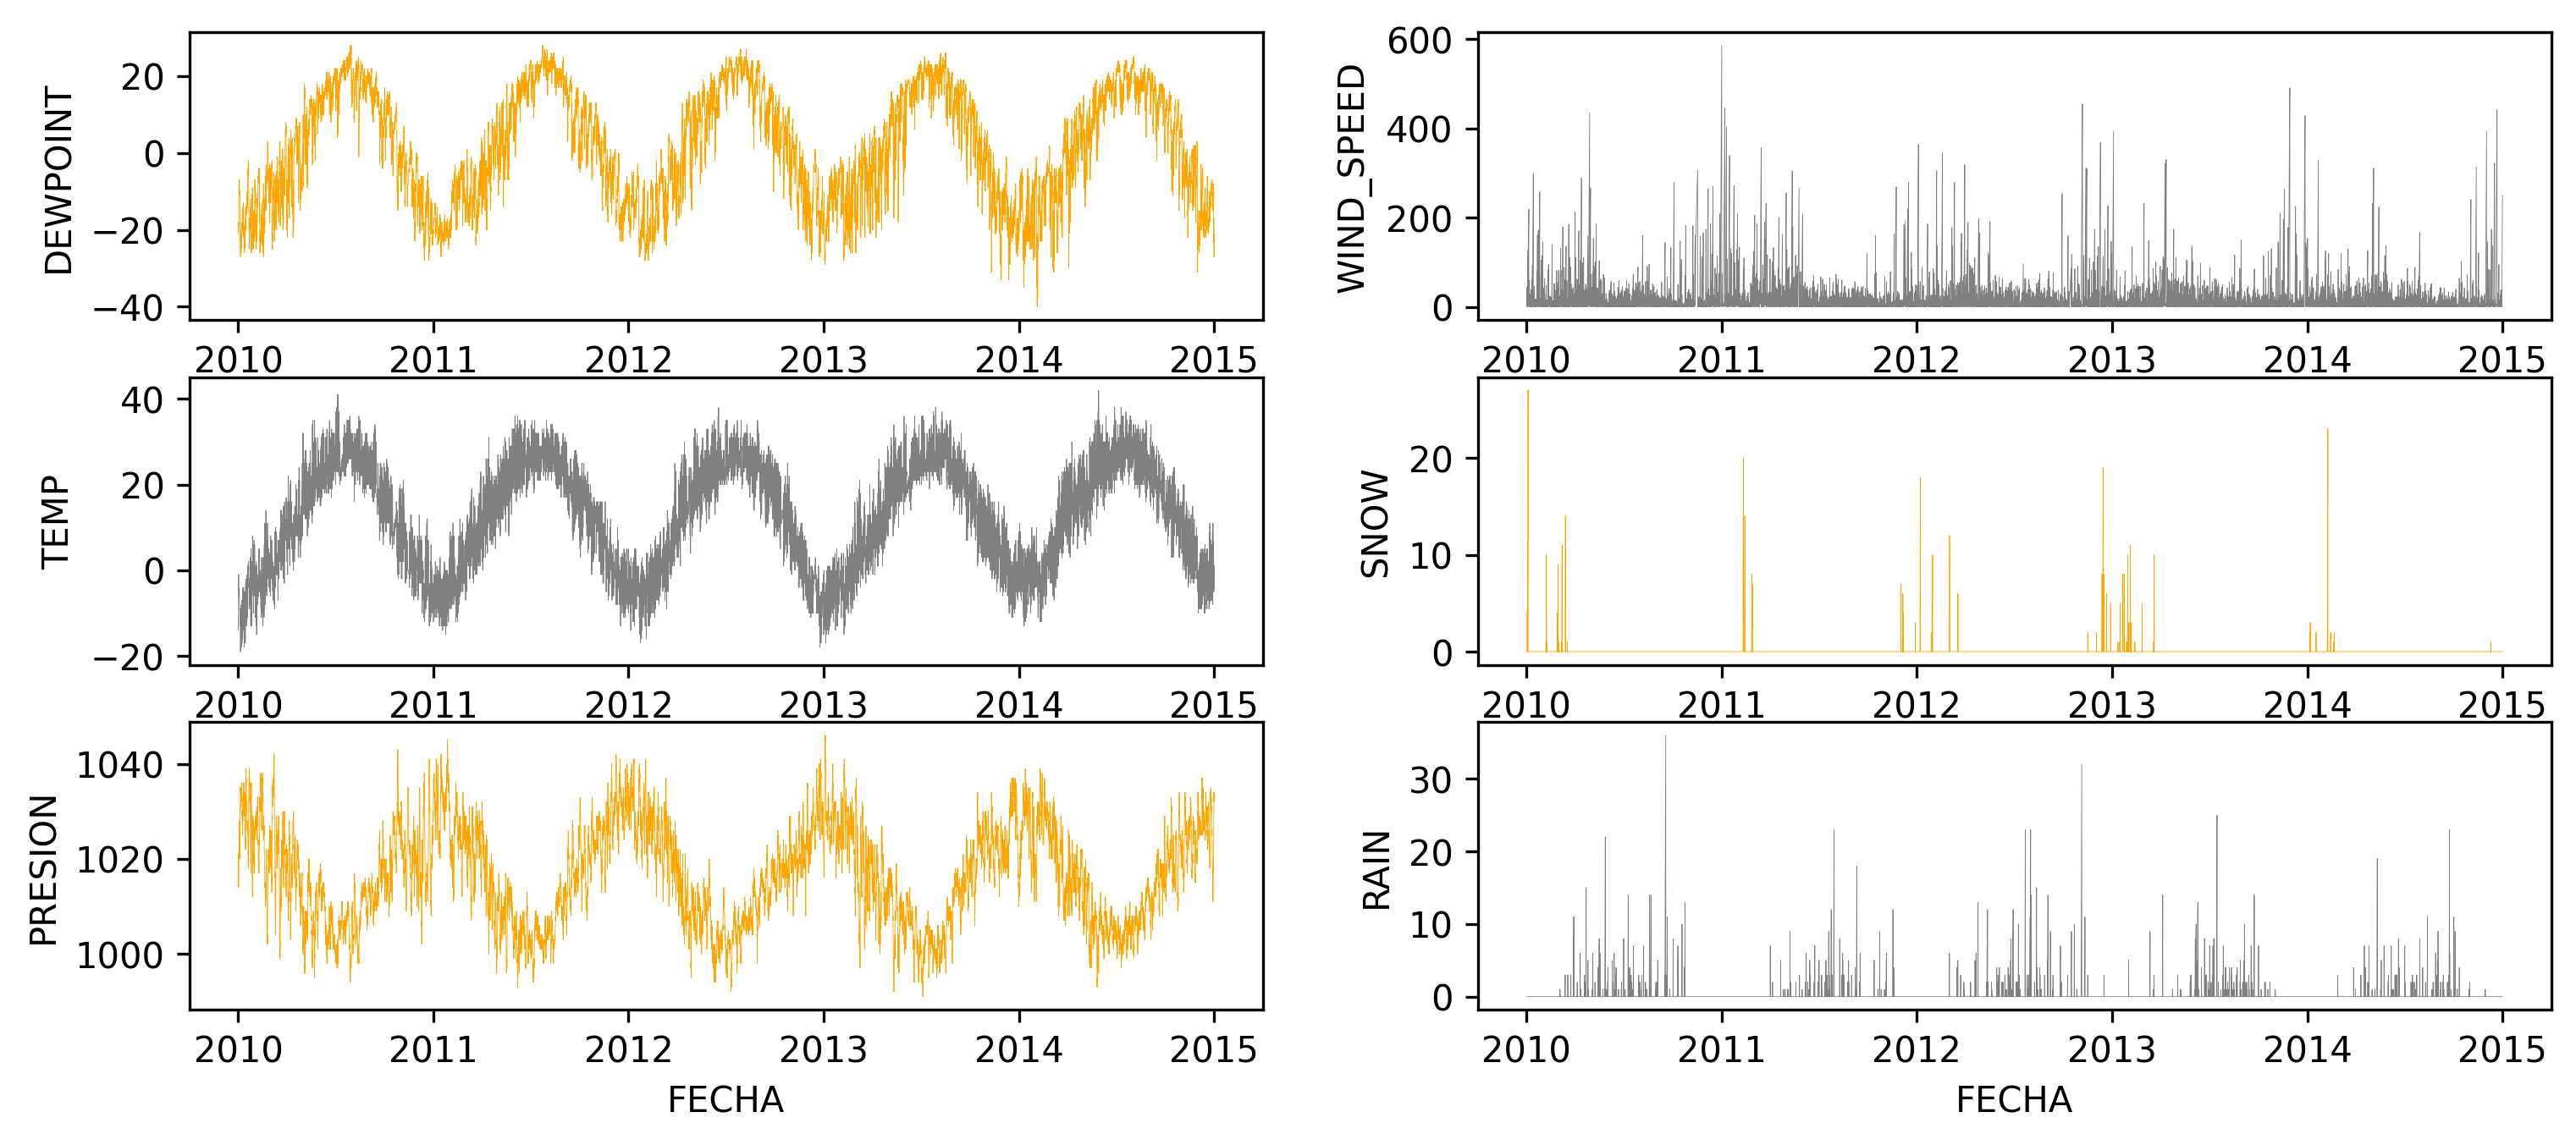

In [102]:
# SERIES DE TIEMPO
# La recomendación de las series de tiempo (en un mismo figure) para todas las variables
plt.rcParams["figure.dpi"] = 300

fig, axs = plt.subplots(3,2, figsize=(12,5))
sns.lineplot(x="FECHA", y="DEWPOINT", data=df, color='orange', linewidth=0.2, ax=axs[0,0])
sns.lineplot(x="FECHA", y="TEMP", data=df, color='grey',linewidth=0.2, ax=axs[1,0])
sns.lineplot(x="FECHA", y="PRESION", data=df,color='orange', linewidth=0.2, ax=axs[2,0])
sns.lineplot(x="FECHA", y="WIND_SPEED", data=df, color='grey', linewidth=0.2, ax=axs[0,1])
sns.lineplot(x="FECHA", y="SNOW", data=df, color='orange', linewidth=0.2, ax=axs[1,1])
sns.lineplot(x="FECHA", y="RAIN", data=df,color='grey', linewidth=0.2, ax=axs[2,1])

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

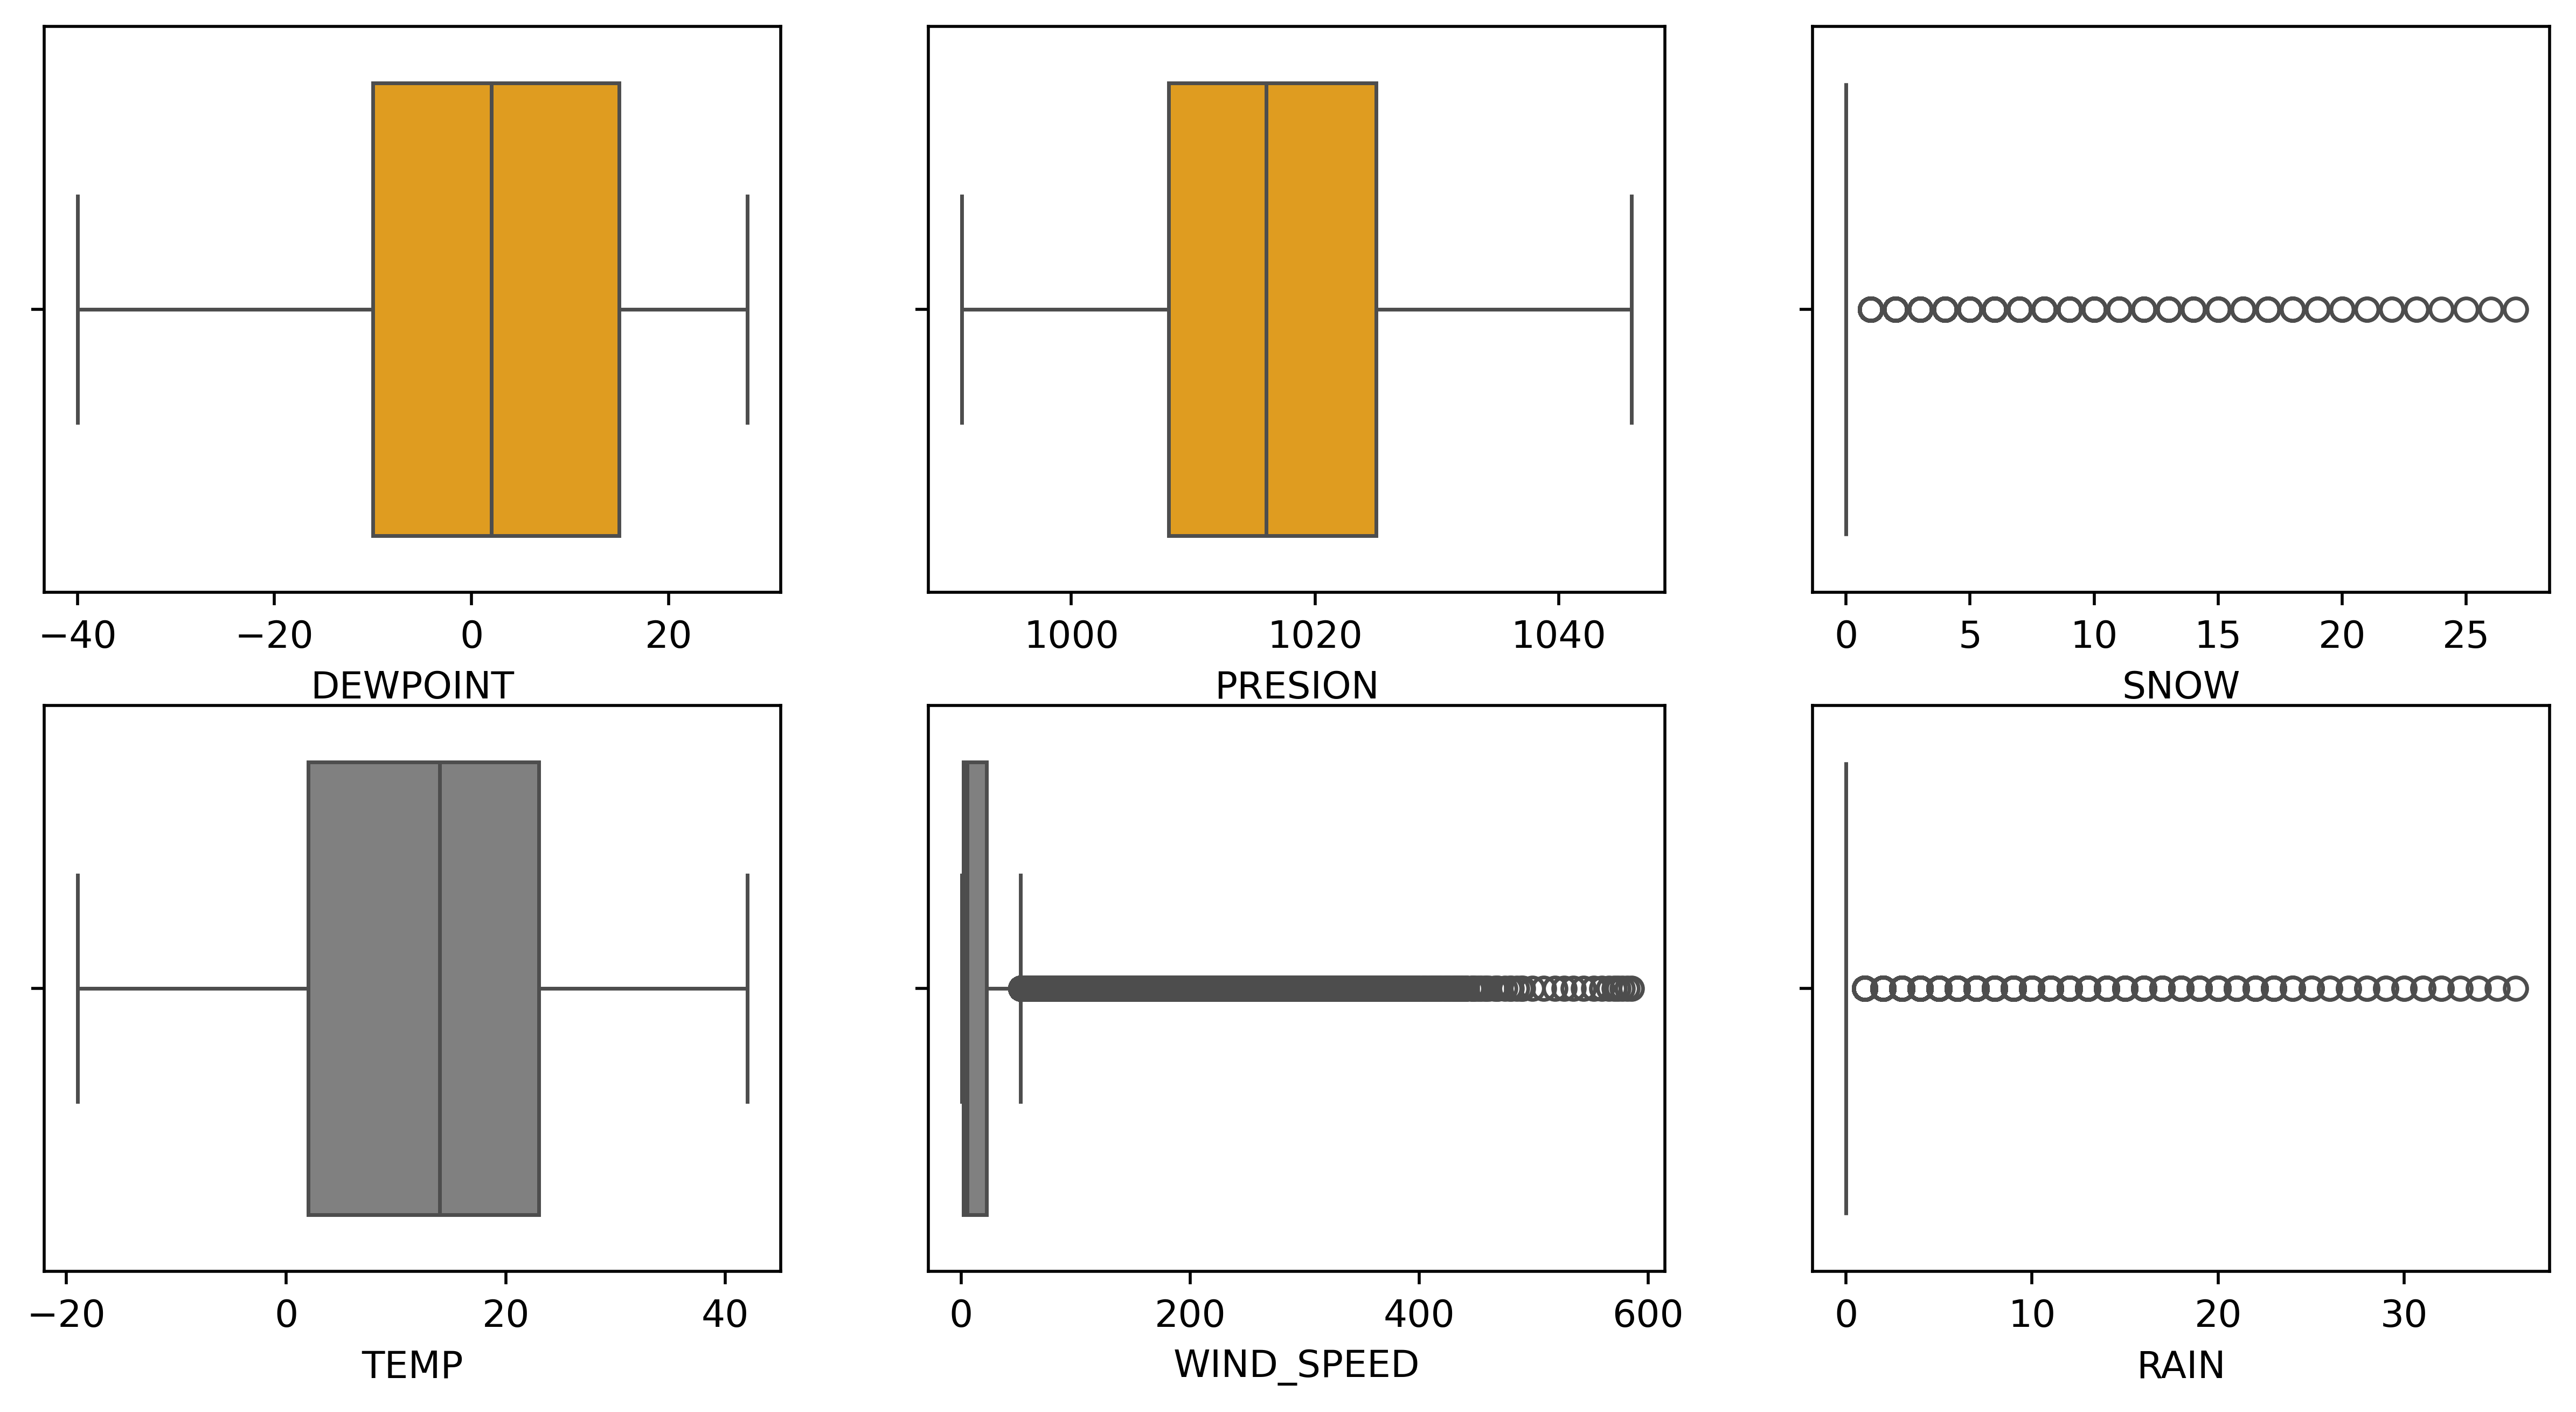

In [115]:
# HISTOGRAMA
# Analisis de outliers para cada variable

plt.rcParams["figure.dpi"] = 500

fig, axs = plt.subplots(2, 3, figsize=(12,6))

sns.boxplot(x="DEWPOINT", data=df, color='orange', ax=axs[0,0])
sns.boxplot(x="TEMP", data=df, color='grey', ax=axs[1,0])
sns.boxplot(x="PRESION", data=df, color='orange', ax=axs[0,1])
sns.boxplot(x="WIND_SPEED", data=df, color='grey', ax=axs[1,1])
sns.boxplot(x="SNOW", data=df, color='orange', ax=axs[0,2])
sns.boxplot(x="RAIN", data=df, color='grey', ax=axs[1,2])

plt.show

# SNOW y RAIN la mayoria de sus valores son 0, por eso la grafica de caja es una linea llena de outliers

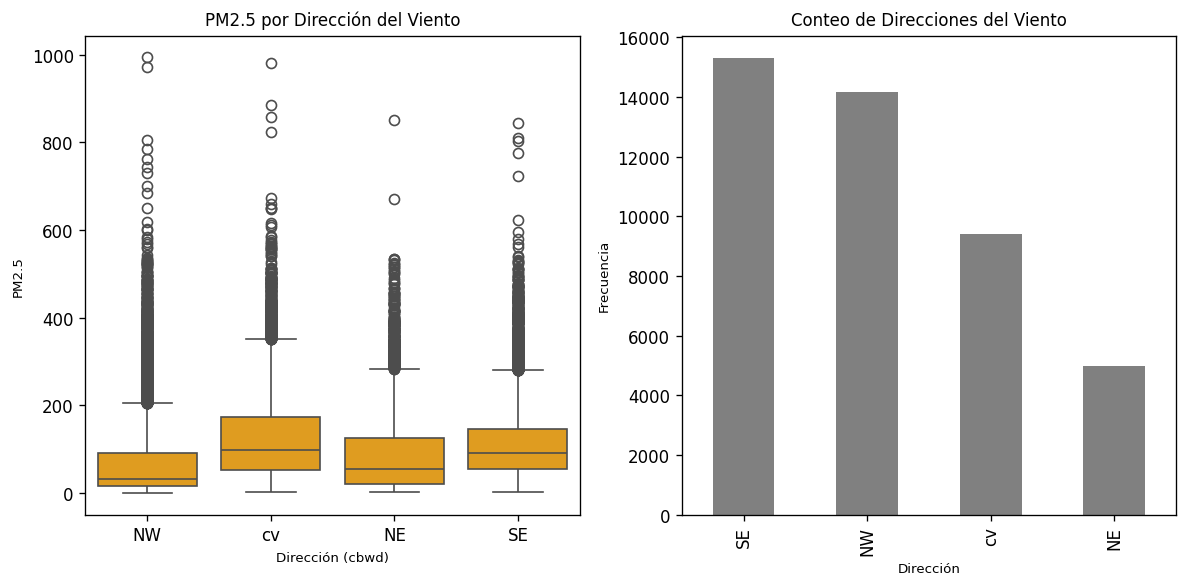

In [153]:
#GRAFICO DE BARRAS Y GRAFICO  DE CAJA Y BIGOTES
# Conteo de categorías
conteo = df['WIND_DIRECTION'].value_counts()

# Crear figura con dos subplots (2 filas, 1 columna)
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=120)

#Gráfico de caja para ver cómo afecta la dirección del viento o su calma ('cbwd') a los valores de PM2.5
sns.boxplot(x='WIND_DIRECTION', y='PM25', color='orange', data=df, ax=axes[0])
axes[0].set_title('PM2.5 por Dirección del Viento', fontsize=10)
axes[0].set_xlabel('Dirección (cbwd)', fontsize=8)
axes[0].set_ylabel('PM2.5', fontsize=8)

# --- Gráfico de barras ---
conteo.plot(kind='bar', color='grey', ax=axes[1])
axes[1].set_title("Conteo de Direcciones del Viento", fontsize=10)
axes[1].set_xlabel("Dirección", fontsize=8)
axes[1].set_ylabel("Frecuencia", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Rellenar nulos con la mediana
# df['pm2.5'] = df['pm2.5'].fillna(df['pm2.5'].median())

El df tiene 43,824 registros.

Para el tratamiento de datos tenemos las siguientes opciones:

- Opción 1: Eliminar nulos "df_clean"

- Opción 2: Rellenar con la media "df_mean"

- Opción 3: Rellenar con interpolación "df_mice"

Agrego lo demas..

In [39]:
print(df.isna().sum())
print(" ")
print("Los valores de la unica columna tipo string (WIND_DIRECTION) son:")
print(df["WIND_DIRECTION"].value_counts())
print("Estos valores se les aplica One-hot encoding al ser muy pocas las categorias")

NO                   0
YEAR                 0
MONTH                0
DAY                  0
HOUR                 0
PM25              2067
DEWPOINT             0
TEMP                 0
PRESION              0
WIND_DIRECTION       0
WIND_SPEED           0
SNOW                 0
RAIN                 0
FECHA                0
FECHA_SIN_H          0
dtype: int64
 
Los valores de la unica columna tipo string (WIND_DIRECTION) son:
WIND_DIRECTION
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64
Estos valores se les aplica One-hot encoding al ser muy pocas las categorias


In [42]:
# df Limpio de NA
df_clean = df.dropna(subset=['PM25'])
print(len(df_clean))

41757


In [41]:
# Dropping Data. Nueva dataset que elimina las files con NAs solo de la columna de pm2.5.

df_clean = df.dropna(subset="PM25")
df_clean.isna().sum()
len(df_clean)

# Impute data. Nuevo dataset imputado... Primero para decidir que tipo de Imputación realizar
# necesito saber que tan independientes o dependientes son mis variables entre si.
# Para ello necesito visualizar posibles correlaciones o relaciones estadisticas entre ellas.

# Dadas las graficas de abajo quiero diferenciar que variables son dependientes de otras, y ver como esto afecta al tipo de imputacion
# despues, normalizamos

41757

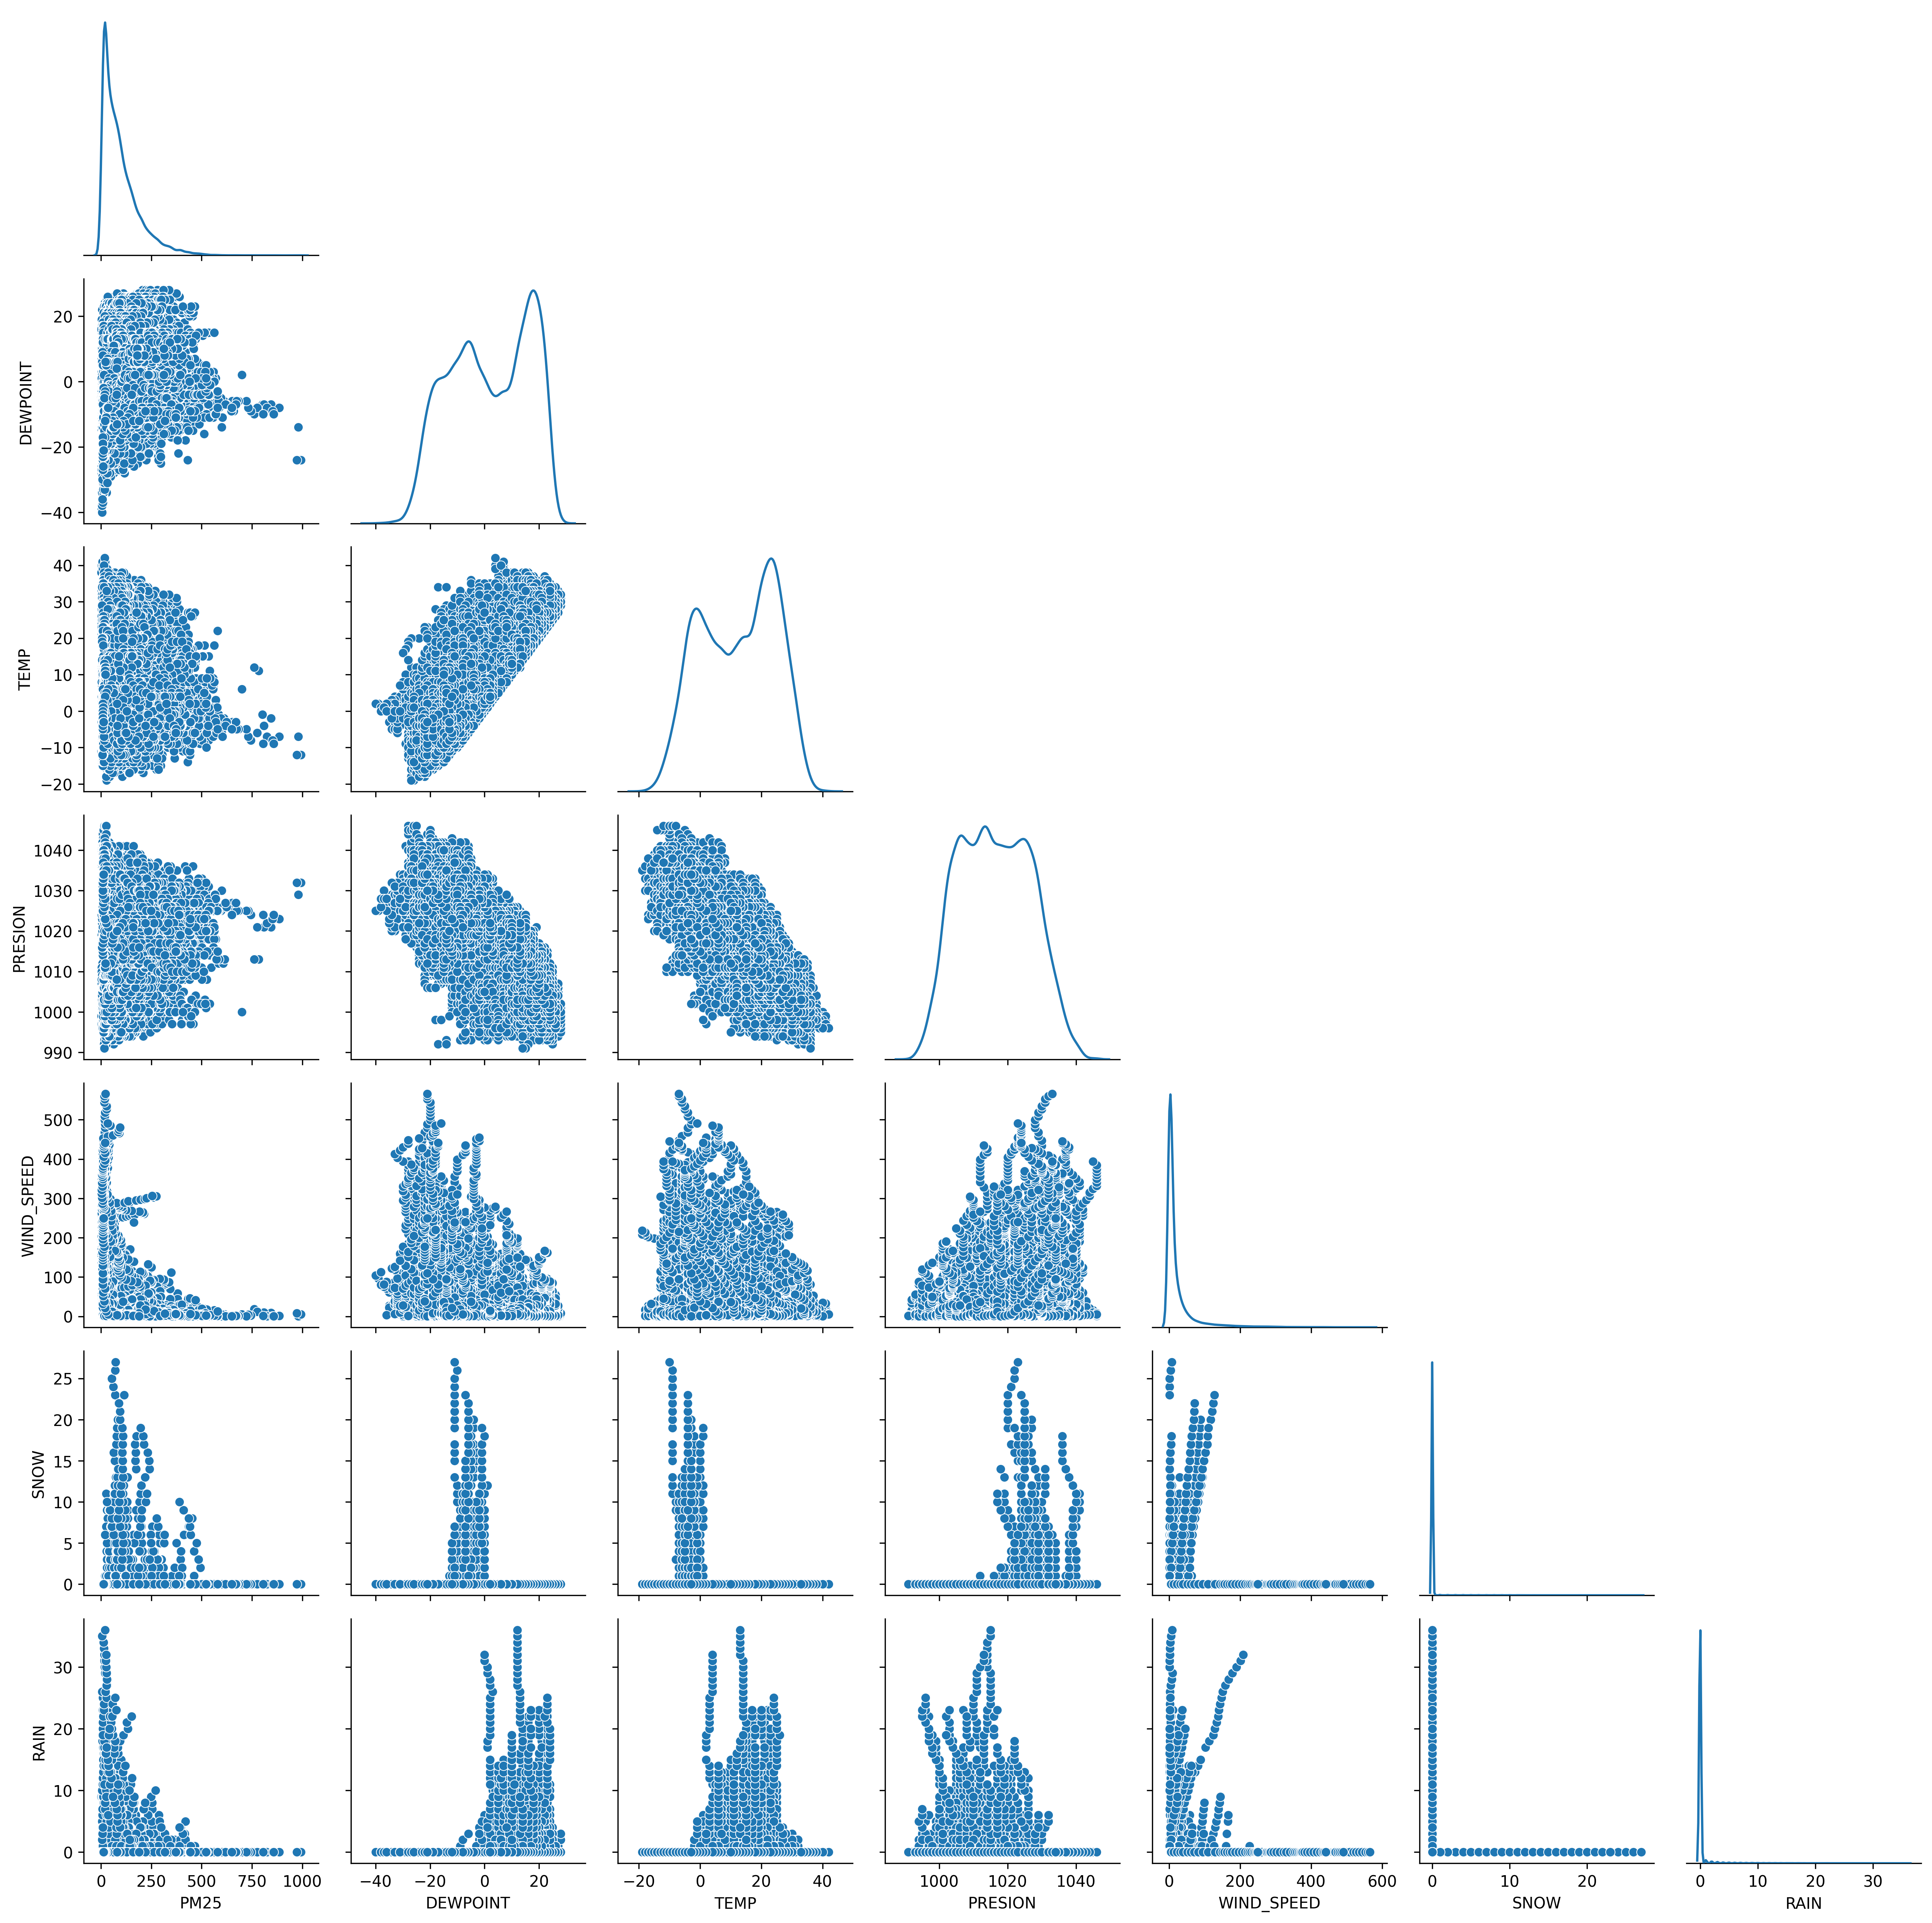

In [43]:
g = sns.PairGrid(df_clean[["PM25", "DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN"]],
                 diag_sharey=False,
                 corner=True
                )
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)
# llevar a la otra fase

In [ ]:
df["FECHA"].sample(3)


42766   2014-11-17 22:00:00
35325   2014-01-11 21:00:00
9945    2011-02-19 09:00:00
Name: FECHA, dtype: datetime64[us]

Preparando los dataset para ML:
- Codificación (One-hot encoding) para la columna `WIND_DIRECTION` (única columna tipo string).
- Creación de datasets con diferentes tipos de IMPUTACION para las columnas `PM25`.
- Normalizar datasets

In [45]:
# One-hot encoding para WIND_DIRECTION.
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[["WIND_DIRECTION"]])
encoded_columns = encoder.get_feature_names_out(["WIND_DIRECTION"])
encoded_df = pd.DataFrame(encoded_data, columns=encoded_columns)
df_final = pd.concat([df.drop('WIND_DIRECTION', axis=1), encoded_df], axis=1)
display(df_final.head(3))

# df_final es nuestro dataframe ya codificado!

# solo como comentario:
# Descubri que pandas tmb lo hace de una forma mas sencilla...
# df_encoded_by_pandas = pd.get_dummies(df, columns=["WIND_DIRECTION"], dtype=int)
# print("\n--- pandas way (.get_dummies) ---")
# display(df_encoded_by_pandas.head(3))

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,1.79,0,0,2010-01-01 00:00:00,2010-01-01,0.0,1.0,0.0,0.0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,4.92,0,0,2010-01-01 01:00:00,2010-01-01,0.0,1.0,0.0,0.0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,6.71,0,0,2010-01-01 02:00:00,2010-01-01,0.0,1.0,0.0,0.0


In [48]:
# Emmanuel: No me queda del todo claro que metodo de imputación elegir lol
# Entonces crearé diferetes dataset con diferentes metodos de imputación
df_imputed_mean = df_final.copy()
df_imputed_median = df_final.copy()

# imputaición con media (no aprecia tanto los outliers)
numeric_imputer_mean = SimpleImputer(strategy="mean")
df_imputed_mean["PM25_IMPUTED_MEAN"] = numeric_imputer_mean.fit_transform(df[["PM25"]])
# imputación con mediana (Maneja mejor los outliers)
numeric_imputer_median = SimpleImputer(strategy="median")
df_imputed_median["PM25_IMPUTED_MEDIAN"] = numeric_imputer_median.fit_transform(df[["PM25"]])

# Aqui nuestras columnas por modelar son:
# - PM25_IMPUTED_MEAN
# - PM25_IMPUTED_MEDIAN

print("Base de datos Imputada")
display(df_imputed_mean.sample(3))
display(df_imputed_median.sample(3))

# Habia otra forma mas rápida con Pandas, otra vez... (solo como observación, otra vez)
# Pero al parecer se recomienda usar la de scikit-learn
# df_encoded_by_pandas["PM25_IMPUTED_MEAN"] = df["PM25"].fillna(df["PM25"].mean())
# df_encoded_by_pandas["PM25_IMPUTED_MEDIAN"] = df["PM25"].fillna(df["PM25"].median())
# print("\nBase de datos Imputada (con pandas)")
# display(df_encoded_by_pandas.head(3))

Base de datos Imputada


,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,PM25_IMPUTED_MEAN
32398,32399,2013,9,11,22,85.0,15,22.0,1014.0,37.12,0,0,2013-09-11 22:00:00,2013-09-11,0.0,0.0,1.0,0.0,85.0
21370,21371,2012,6,9,10,178.0,20,27.0,999.0,3.58,0,0,2012-06-09 10:00:00,2012-06-09,0.0,0.0,1.0,0.0,178.0
32321,32322,2013,9,8,17,138.0,18,25.0,1014.0,3.57,0,0,2013-09-08 17:00:00,2013-09-08,0.0,0.0,0.0,1.0,138.0


,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,PM25_IMPUTED_MEDIAN
32164,32165,2013,9,2,4,33.0,14,17.0,1015.0,0.45,0,0,2013-09-02 04:00:00,2013-09-02,0.0,0.0,0.0,1.0,33.0
30958,30959,2013,7,13,22,140.0,22,27.0,1007.0,33.09,0,0,2013-07-13 22:00:00,2013-07-13,0.0,0.0,1.0,0.0,140.0
1688,1689,2010,3,12,8,19.0,-15,4.0,1018.0,88.51,0,0,2010-03-12 08:00:00,2010-03-12,0.0,1.0,0.0,0.0,19.0


In [49]:
# K-Nearest Neighbors (KNN), este tipo de imputación es bueno para datasets con variables agrupadas
# Que WIND_DIRECTION es la única variable categorica (factor)

df_numerico = df_final.select_dtypes(include=["number"])

knn_imputer = KNNImputer(n_neighbors=2)
imputed_data = knn_imputer.fit_transform(df_numerico)
df_imputed_KNN = pd.DataFrame(imputed_data, columns=df_numerico.columns)

# df_imputer_KNN es nuestro dataframe con metodo de imputación KNN
# en este la variable a modelas sigue siendo PM25

display(df_imputed_KNN.head(3))
display(df_imputed_KNN.isnull().sum())

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv
0,1.0,2010.0,1.0,1.0,0.0,138.5,-21.0,-11.0,1021.0,1.79,0.0,0.0,0.0,1.0,0.0,0.0
1,2.0,2010.0,1.0,1.0,1.0,138.5,-21.0,-12.0,1020.0,4.92,0.0,0.0,0.0,1.0,0.0,0.0
2,3.0,2010.0,1.0,1.0,2.0,138.5,-21.0,-11.0,1019.0,6.71,0.0,0.0,0.0,1.0,0.0,0.0


,0
NO,0
YEAR,0
MONTH,0
DAY,0
HOUR,0
PM25,0
DEWPOINT,0
TEMP,0
PRESION,0
WIND_SPEED,0


In [50]:
# Iterative Imputation (MICE), supuestamente el mejor

mice_imputer = IterativeImputer(max_iter=10, random_state=0)
mice_imputer_data = mice_imputer.fit_transform(df_numerico)
df_imputed_mice = pd.DataFrame(mice_imputer_data, columns=df_numerico.columns)

# df_imputed_mice
# vairable a modelar imputada: PM25

display(df_imputed_mice.head(3))
display(df_imputed_mice.isnull().sum())

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv
0,1.0,2010.0,1.0,1.0,0.0,115.068227,-21.0,-11.0,1021.0,1.79,0.0,0.0,0.0,1.0,0.0,0.0
1,2.0,2010.0,1.0,1.0,1.0,123.984317,-21.0,-12.0,1020.0,4.92,0.0,0.0,0.0,1.0,0.0,0.0
2,3.0,2010.0,1.0,1.0,2.0,119.908046,-21.0,-11.0,1019.0,6.71,0.0,0.0,0.0,1.0,0.0,0.0


,0
NO,0
YEAR,0
MONTH,0
DAY,0
HOUR,0
PM25,0
DEWPOINT,0
TEMP,0
PRESION,0
WIND_SPEED,0


In [ ]:
# Para el escalado de variables, dado las propiedades de outliers de nuestro dataset
# Elegimos RobustScaler
# robust = RobustScaler()

# Preprocesamos los datos: Estadarización

# Para df_clean

cols_to_scale = ["DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN"]

ct = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), cols_to_scale)
    ],
    remainder='passthrough'
)

# Fit and transform the data
# Note: By default, this outputs a NumPy array or a Pandas DataFrame depending on your sklearn configuration
scaled_array = ct.fit_transform(df)
# Para df_imputed_mice




,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN
0,-21,-11.0,1021.0,1.79,0,0
1,-21,-12.0,1020.0,4.92,0,0
2,-21,-11.0,1019.0,6.71,0,0
3,-21,-14.0,1019.0,9.84,0,0
4,-20,-12.0,1018.0,12.97,0,0


In [52]:
# Expotar .csv
# Livia: no me corria la caja de código anterior y segun yo con esto se arregla
# y ya podemos ver esos DFs con los nombres con el sub "_clean" y "_mice"
df_clean.to_csv("PRSA_data_clean.csv", sep='\t', encoding='utf-8', index=False, header=True)
df_imputed_mice.to_csv("PRSA_data_mice.csv", sep='\t', encoding='utf-8', index=False, header=True)

# **Programaciones NO usadas o eliminadas del flujo final**

Si corren...

<function matplotlib.pyplot.show(close=None, block=None)>

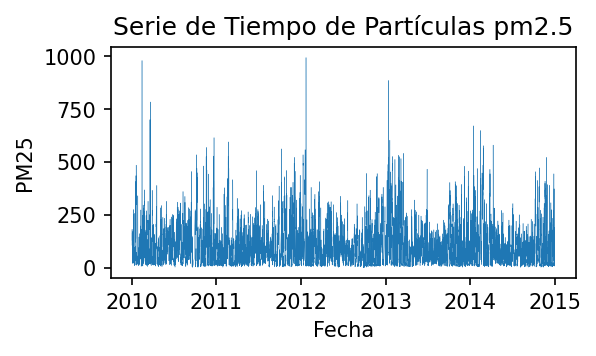

In [98]:
# SERIE DE TIEMPO
# Configuración de los gráficos
plt.figure(figsize=(4, 2))

# 1. Gráfico para ver la serie
sns.lineplot(x="FECHA", y="PM25", data=df, linewidth=0.2)
plt.title('Serie de Tiempo de Partículas pm2.5')
plt.xlabel('Fecha')

plt.show

Text(0.5, 0, 'Concentración μg/m³')

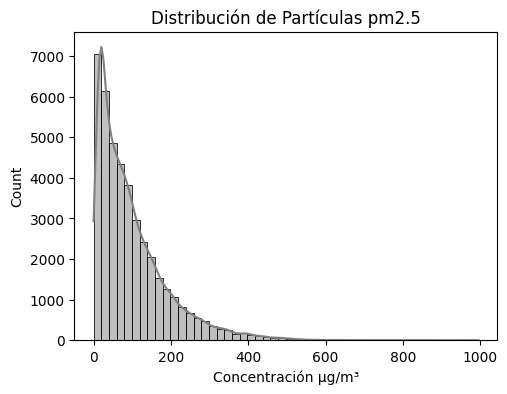

In [15]:
# HISTOGRAMA
# Configuración de los gráficos
plt.figure(figsize=(12, 4))

# Gráfico para ver la distribución de pm2.5 e identificar sesgos o valores atípicos (outliers)
plt.subplot(1, 2, 1)
sns.histplot(df['PM25'].dropna(), bins=50, kde=True, color='grey')
plt.title('Distribución de Partículas pm2.5')
plt.xlabel('Concentración μg/m³')

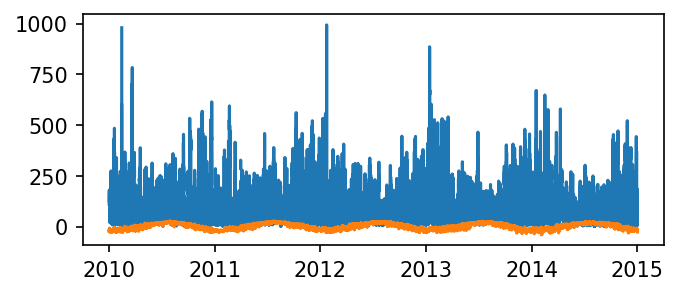

In [82]:
plt.figure(figsize=(5, 2))
plt.plot(df["FECHA"], df["PM25"], label="pm2.5")
plt.plot(df["FECHA"], df["DEWPOINT"], label="DEWP")